# Frontier RCCL-Allreduce — Plots

Raw data = OSU text output under `results/sweep/N<nodes>_job<id>/{A,B,C,D}_*.txt` (main sweep)
and `results_ml/` (ML gradient-sync at exact model sizes), parsed in **cell 1** into DataFrames
`data` and `data_ml`. Each point is the **median across reps** (3 reps at 1–2048 nodes, 2 at 4096;
each rep = mean over 50 iterations, 10 warm-ups). **Cell 2** defines the styling and all plot
functions (collapse it to hide the code). Every cell after that is a **one-line call**.

Each axis shows a small italic "lower/higher is better" note beside its label. Configs:
MPICH (host CPU) / MPICH (device) / **MPICH-RCCL** / Cray MPICH. The **Cray MPICH** plotted is
the BLK=128 MB-tuned configuration (see NOTES); the default config crashes >4 MiB at ≥1024 nodes
and is retired from the plots. 128 MB is the smallest staging buffer that avoids the GPU-allreduce
fault at *every* scale (BLK=64 MB rescues only through 4096 nodes, then faults >32 MiB at 8192), so
it is used uniformly across the whole ladder rather than switching block sizes mid-dataset.

Message-size coverage (intentional, not data gaps):
- **MPICH-RCCL (C): 8 B → 1 GiB at every node count (1–4096).** 1 GiB is OSU's ceiling (32-bit message size).
- **Cray MPICH (D, BLK=128 MB tuned): full sweep to 4 GiB at every node count (1–8192).** The
  *default* (untuned) Cray path crashes with a GPU memory access fault above 4 MiB at ≥1024 nodes;
  the BLK=128 MB staging buffer carries the tuned line across the full range at all scales.
- **CPU paths (A/B): capped at 32 MiB** — host reductions are prohibitively slow at large sizes.

In [33]:
# === Cell 1: load & clean the sweep data =================================
import os, re, glob
import numpy as np, pandas as pd

RESULTS = "results_sweep" if os.path.isdir("results_sweep") else "../results_sweep"

OSU_FILES = {"A":"A_mpich_host.txt","B":"B_mpich_dev.txt",
             "C":"C_mpich_rccl.txt","D":"D_cray_gpuaware.txt"}
LABEL = {"A":"MPICH (host CPU)","B":"MPICH (device)","C":"MPICH-RCCL",
         "D":"Cray MPICH (default 8MB\u2020)","E":"RCCL (rccl-tests)",
         "K":"Cray MPICH (kernel-off\u2020)",   # \u2020 = non-default workaround configs
         "T":"Cray MPICH"}   # BLK=128MB tuned config = THE Cray line on all plots (detail in NOTES/report)

def parse_osu(path):
    out = []
    for line in open(path):
        p = line.split()
        if len(p) >= 2 and p[0].isdigit():
            try:
                out.append((int(p[0]), float(p[1]),
                            float(p[2]) if len(p) > 2 else np.nan,
                            float(p[3]) if len(p) > 3 else np.nan))
            except ValueError:
                pass
    return out

rows = []
for d in sorted(glob.glob(os.path.join(RESULTS, "N*_job*"))):
    m = re.match(r"N(\d+)_job(\d+)", os.path.basename(d))
    if not m:
        continue
    nodes, job = int(m.group(1)), int(m.group(2))
    for cfg, fn in OSU_FILES.items():
        fp = os.path.join(d, fn)
        if os.path.exists(fp):
            for s, a, mn, mx in parse_osu(fp):
                rows.append(dict(nodes=nodes, job=job, config=cfg, size=s, avg=a, min=mn, max=mx))

raw = pd.DataFrame(rows); raw = raw[raw["avg"] > 0]
data = (raw.groupby(["nodes","config","size"], as_index=False)
           .agg(avg=("avg","median"), std=("avg","std"), nreps=("job","nunique")))   # median across reps: robust to one bad-placement rep

# Path-2 ML data (exact model-gradient sizes) if results_ml/ is present; else plot_ml_sync uses Path 1.
ML_RESULTS = "results_ml" if os.path.isdir("results_ml") else "../results_ml"
ml_rows = []
for d in sorted(glob.glob(os.path.join(ML_RESULTS, "N*_job*"))):
    m = re.match(r"N(\d+)_job(\d+)", os.path.basename(d))
    if not m:
        continue
    for cfg, fn in OSU_FILES.items():
        fp = os.path.join(d, fn)
        if os.path.exists(fp):
            for s, a, mn, mx in parse_osu(fp):
                ml_rows.append(dict(nodes=int(m.group(1)), job=int(m.group(2)), config=cfg, size=s, avg=a))
_mlraw = pd.DataFrame(ml_rows)
data_ml = (_mlraw[_mlraw["avg"] > 0]
           .groupby(["nodes","config","size"], as_index=False)
           .agg(avg=("avg","median"), nreps=("job","nunique"))) if len(ml_rows) else None

# Knob-Cray: MPICH_GPU_ALLREDUCE_USE_KERNEL=0 workaround at >=1024 (non-default Cray config,
# kept as its own config "K" so it never mixes with default-D). Sweep + ML files.
KNOB_RESULTS = "results_crayknob" if os.path.isdir("results_crayknob") else "../results_crayknob"
knob_rows, knob_ml = [], []
for d in sorted(glob.glob(os.path.join(KNOB_RESULTS, "N*_job*"))):
    m = re.match(r"N(\d+)_job(\d+)", os.path.basename(d))
    if not m:
        continue
    n, job = int(m.group(1)), int(m.group(2))
    for fn, sink in [("D_kernel0_sweep.txt", knob_rows), ("D_kernel0_ml.txt", knob_ml)]:
        fp = os.path.join(d, fn)
        if os.path.exists(fp):
            for s, a, mn, mx in parse_osu(fp):
                sink.append(dict(nodes=n, job=job, config="K", size=s, avg=a))
if knob_rows:
    _k = pd.DataFrame(knob_rows)
    data = pd.concat([data, _k[_k["avg"] > 0].groupby(["nodes","config","size"], as_index=False)
                      .agg(avg=("avg","median"), std=("avg","std"), nreps=("job","nunique"))],
                     ignore_index=True)
if knob_ml and data_ml is not None:
    _km = pd.DataFrame(knob_ml)
    data_ml = pd.concat([data_ml, _km[_km["avg"] > 0].groupby(["nodes","config","size"], as_index=False)
                         .agg(avg=("avg","median"), nreps=("job","nunique"))], ignore_index=True)

# Tuned Cray (config "T"): kernel path ON with the BLK=128MB GPU-allreduce staging buffer.
# THE plotted Cray line is BLK=128MB ONLY (results_crayblk128/, files D_blk128_*). 128MB is the
# smallest single buffer that avoids the fault at EVERY scale (64MB faults >32 MiB at 8192). We
# deliberately do NOT fall back to the retired 64MB ladder: a node count with no 128MB data simply
# shows a GAP on the plots, so what's drawn is exactly what was measured at the standardized block
# size. (results_crayblk64/ + the N*_blkbig_* probe dirs are kept on disk as evidence, not loaded.)
def _load_tuned(dirname, sweep_fn, ml_fn):
    root = dirname if os.path.isdir(dirname) else os.path.join("..", dirname)
    sw, ml = [], []
    for d in sorted(glob.glob(os.path.join(root, "N*_job*"))):
        m = re.match(r"N(\d+)_job(\d+)", os.path.basename(d))
        if not m:
            continue
        n, job = int(m.group(1)), int(m.group(2))
        for fn, sink in [(sweep_fn, sw), (ml_fn, ml)]:
            fp = os.path.join(d, fn)
            if os.path.exists(fp):
                for s, a, mn, mx in parse_osu(fp):
                    sink.append(dict(nodes=n, job=job, config="T", size=s, avg=a))
    return sw, ml
t_rows, t_ml = _load_tuned("results_crayblk128", "D_blk128_sweep.txt", "D_blk128_ml.txt")
if t_rows:
    _t = pd.DataFrame(t_rows)
    data = pd.concat([data, _t[_t["avg"] > 0].groupby(["nodes","config","size"], as_index=False)
                      .agg(avg=("avg","median"), std=("avg","std"), nreps=("job","nunique"))], ignore_index=True)
if t_ml and data_ml is not None:
    _tm = pd.DataFrame(t_ml)
    data_ml = pd.concat([data_ml, _tm[_tm["avg"] > 0].groupby(["nodes","config","size"], as_index=False)
                         .agg(avg=("avg","median"), nreps=("job","nunique"))], ignore_index=True)

print("main sweep nodes:", sorted(data.nodes.unique()), "| sizes:", data["size"].nunique(),
      "| ML Path-2:", ("loaded, nodes " + str(sorted(data_ml.nodes.unique()))) if data_ml is not None else "none (uses Path 1)")
data.head()

main sweep nodes: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096), np.int64(8192)] | sizes: 31 | ML Path-2: loaded, nodes [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096), np.int64(8192)]


,nodes,config,size,avg,std,nreps
0,1,A,4,17.28,3.151545,3
1,1,A,8,16.95,0.181475,3
2,1,A,16,16.86,0.122202,3
3,1,A,32,27.48,0.200333,3
4,1,A,64,28.20,0.705856,3


In [34]:
# === Cell 2: style + plot functions  (collapse this cell to hide the code) =
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams["font.family"] = "STIXGeneral"; mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams.update({"font.size":18,"axes.titlesize":22,"axes.labelsize":20,
                     "legend.fontsize":13,"xtick.labelsize":16,"ytick.labelsize":16})

SPEEDUP_COLOR = "#2ca02c"          # green reserved for the speedup line only
LAT_MAIN = "Latency (\u00b5s, log)"
SPD_MAIN = lambda base: f"{LABEL['C']} speedup vs {LABEL[base]}"
STYLE = {   # all data lines uniform: solid, circle markers, same weight (distinguished by color)
    "A": dict(color="#616161", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["A"]),
    "B": dict(color="#1f77b4", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["B"]),
    "C": dict(color="#d62728", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["C"]),
    "D": dict(color="#7e4bbd", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["D"]),
    "K": dict(color="#b39ddb", marker="o", linestyle="--", linewidth=2, markersize=5,
              markerfacecolor="none", label=LABEL["K"]),   # lighter dashed purple: kernel-off workaround
    "T": dict(color="#7e4bbd", marker="o", linestyle="-", linewidth=2, markersize=5,
              label=LABEL["T"]),                            # T is THE Cray line: original purple, solid
}
ORDER = ["A","B","C"]               # default-D retired from plots (T = the Cray line); E parsed, not plotted
def cray_cfg():                     # what "Cray MPICH" means on the plots
    return "T" if (data.config == "T").any() else "D"

def sci(x,_):
    if x <= 0: return "0"
    e = int(np.floor(np.log10(x))); b = x/10**e
    return rf"${int(round(b))}\times10^{{{e}}}$"

def human(nb):
    nb = float(nb)
    for u in ["B","KiB","MiB","GiB"]:
        if nb < 1024: return f"{int(nb)} {u}"
        nb /= 1024
    return f"{int(nb)} TiB"

def parse_size(x):
    # accept "1MiB", "512KiB", "1GiB", "8B", "1kb", ... or a raw byte count
    if isinstance(x, (int, float)): return int(x)
    s = str(x).strip().lower().replace(" ", "")
    for suf, m in [("gib",1024**3),("gb",1024**3),("mib",1024**2),("mb",1024**2),
                   ("kib",1024),("kb",1024),("b",1),("g",1024**3),("m",1024**2),("k",1024)]:
        if s.endswith(suf):
            return int(float(s[:-len(suf)]) * m)
    return int(float(s))

def series(nodes, config):
    d = data[(data.nodes==nodes)&(data.config==config)].sort_values("size")
    return d["size"].values, d["avg"].values

def ylabel2(ax, main, sub, side="left"):
    # main axis label + a small italic light-gray "sub" line just outboard of it
    if side == "left":
        lbl = ax.set_ylabel(main); rot, dx = 90, -20
    else:
        lbl = ax.set_ylabel(main, rotation=270, labelpad=42); rot, dx = 270, 20
    ax.annotate(sub, xy=(0.5,0.5), xycoords=lbl, textcoords="offset points",
                xytext=(dx,0), rotation=rot, ha="center", va="center",
                fontsize=12.5, style="italic", color="#444444")

def annotate_max(fig, ax_host, ax_data, x, y, text, boxcolor="black"):
    # place a boxed "N.Nx" label near (x,y) WITHOUT covering any plotted line:
    # try candidate offsets, keep those inside the axes, pick the one farthest from all data points
    fig.canvas.draw()
    pts = []
    for a in fig.axes:
        for ln in a.get_lines():
            xd = np.asarray(ln.get_xdata(), dtype=float)
            if xd.size <= 2 and ln.get_marker() in ("", "None", None):
                continue                      # skip axhlines etc.
            pts.append(a.transData.transform(np.column_stack([xd, ln.get_ydata()])))
    P = np.vstack(pts) if pts else np.empty((0, 2))
    anchor = ax_data.transData.transform((x, y))
    bb = ax_host.get_window_extent()
    best, best_score = (0, -45), -1.0
    for off in [(-75,-30),(-75,25),(55,-30),(55,25),(0,-50),(0,40),(-110,0),(80,0),(-75,-60),(55,-60)]:
        cand = anchor + np.array(off)
        if not (bb.x0+30 < cand[0] < bb.x1-30 and bb.y0+20 < cand[1] < bb.y1-20):
            continue
        score = np.min(np.hypot(P[:,0]-cand[0], P[:,1]-cand[1])) if len(P) else 1e9
        if score > best_score:
            best_score, best = score, off
    # draw on the TOP axes (ax_host is composited above ax_data), else the latency
    # lines paint over the white box; transform the anchor into host coordinates.
    xh, yh = ax_host.transData.inverted().transform(anchor)
    ax_host.annotate(text, xy=(xh, yh), xytext=best, textcoords="offset points",
                     fontsize=15, ha="center", va="center", zorder=20,
                     bbox=dict(fc="white", ec=boxcolor, boxstyle="round,pad=0.3"),
                     arrowprops=dict(arrowstyle="->", color=boxcolor))

def finish(fig):
    fig.patch.set_facecolor("white"); fig.tight_layout(); plt.show()

def plot_latency_vs_size(nodes, speedup_over=None):
    if speedup_over is None: speedup_over = cray_cfg()
    fig, ax1 = plt.subplots(figsize=(16,10))
    xall = []
    wcfg = "T" if (data.config == "T").any() else "K"   # tuned Cray preferred; kernel-off fallback
    for cfg in ORDER + ([wcfg] if (data.config == wcfg).any() else []):
        x,y = series(nodes,cfg)
        if len(x): ax1.plot(x,y,**STYLE[cfg]); xall += [x.min(), x.max()]
    ax1.set_xscale("log", base=2); ax1.set_yscale("log")
    if xall:
        ax1.set_xlim(min(xall)/1.5, max(xall)*1.5)   # end the axis at the data, not the next tick
        t, ticks = max(xall), []                      # identical series on all size plots: 4 GiB, 256 MiB, ... 16 B
        while t >= min(xall): ticks.append(t); t /= 16
        ax1.set_xticks(ticks)
    ax1.xaxis.set_major_formatter(FuncFormatter(lambda x,_: human(x) if x >= 1 else ""))
    ax1.set_xlabel("Message size (log scale)")
    ylabel2(ax1, LAT_MAIN, "lower is better", "left")
    ax1.set_title(f"Allreduce latency: {nodes} node(s)")
    ax1.yaxis.set_major_formatter(FuncFormatter(sci)); ax1.grid(True, which="both", ls="--", alpha=0.4)
    xc,yc = series(nodes,"C"); xb,yb = series(nodes,speedup_over)
    common = np.intersect1d(xc, xb) if (len(xc) and len(xb)) else np.array([])
    if len(common):                       # need sizes present in BOTH series (sparse/partial data may not overlap)
        sc = np.array([yb[list(xb).index(s)]/yc[list(xc).index(s)] for s in common])
        ax2 = ax1.twinx()
        ax1.set_zorder(ax2.get_zorder()+1); ax1.patch.set_visible(False)   # data lines above the ax2 baseline
        ax2.plot(common, sc, marker="o", linestyle="--", color=SPEEDUP_COLOR, lw=2, label=f"RCCL speedup vs Cray")
        xk,yk = series(nodes,wcfg) if wcfg != speedup_over else (np.array([]), np.array([]))  # skip when it would duplicate the primary
        if len(xk):
            commonk = np.intersect1d(xc,xk)
            sck = np.array([yk[list(xk).index(s)]/yc[list(xc).index(s)] for s in commonk])
            ax2.plot(commonk, sck, marker="o", linestyle="--", color="#90d890", lw=2,
                     label=f"{LABEL['C']} speedup vs {LABEL[wcfg]}")
        ax2.axhline(1, color="#aaaaaa", ls="--", lw=1.5, zorder=0); ax2.set_yscale("log", base=2)
        ylabel2(ax2, f"{LABEL['C']} speedup" if len(xk) else SPD_MAIN(speedup_over), "higher is better", "right")
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y,_: (f"{y:g}" if y>=1 else "")))
        i = int(np.argmax(sc))
        annotate_max(fig, ax1, ax2, common[i], sc[i], f"{sc[i]:.1f}\u00d7", boxcolor=SPEEDUP_COLOR)
        if len(xk) and len(sck):
            ik = int(np.argmax(sck))
            annotate_max(fig, ax1, ax2, commonk[ik], sck[ik], f"{sck[ik]:.1f}\u00d7", boxcolor="#90d890")
        h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, loc="upper left", framealpha=1)
    else:
        ax1.legend(loc="upper left", framealpha=1)
    finish(fig)

def plot_speedup_vs_size(baseline=None):
    if baseline is None: baseline = cray_cfg()
    fig, ax = plt.subplots(figsize=(16,10))
    xall = []
    for n in sorted(data.nodes.unique()):
        xc,yc = series(n,"C"); xb,yb = series(n,baseline)
        common = np.intersect1d(xc,xb)
        if not len(common): continue
        sc = np.array([yb[list(xb).index(s)]/yc[list(xc).index(s)] for s in common])
        ax.plot(common, sc, marker="o", linestyle="-", lw=2, label=f"{n} nodes")
        xall += [common.min(), common.max()]
    ax.axhline(1, color="#aaaaaa", ls="--", lw=1.5, zorder=0)
    ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
    if xall:
        ax.set_xlim(min(xall)/1.5, max(xall)*1.5)
        t, ticks = max(xall), []
        while t >= min(xall): ticks.append(t); t /= 16
        ax.set_xticks(ticks)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_: (f"{y:g}" if y>=1 else "")))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: human(x) if x >= 1 else ""))
    ax.set_xlabel("Message size (log scale)")
    ylabel2(ax, SPD_MAIN(baseline), "higher is better", "left")
    ax.set_title(f"{LABEL['C']} speedup over {LABEL[baseline]} (per node count)")
    ax.grid(True, which="both", ls="--", alpha=0.4); ax.legend(title="scale", framealpha=1, ncol=2)
    finish(fig)

def plot_scaling(size):
    size = parse_size(size)
    fig, ax = plt.subplots(figsize=(16,10))
    wcfg = "T" if (data.config == "T").any() else "K"
    for cfg in ORDER + ([wcfg] if (data.config == wcfg).any() else []):
        d = data[(data.config==cfg)&(data["size"]==size)].sort_values("nodes")
        if len(d): ax.plot(d.nodes, d.avg, **STYLE[cfg])
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xticks(sorted(data.nodes.unique()))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{int(x)}"))
    ax.set_xlabel("Nodes")
    ylabel2(ax, LAT_MAIN, "lower is better", "left")
    ax.set_title(f"Allreduce scaling @ {human(size)}")
    ax.yaxis.set_major_formatter(FuncFormatter(sci)); ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(framealpha=1)
    finish(fig)

def plot_crossover(baseline=None, annotate=True, vmax=None):
    if baseline is None: baseline = cray_cfg()
    # linear diverging color centered at 1x (= equal); extremes saturate red/blue.
    # cell text = linear speedup (>1 = MPICH-RCCL faster). vmax caps the red end.
    pc = data[data.config=="C"].pivot_table(index="size", columns="nodes", values="avg")
    if baseline in ("Dk", "Dt"):   # composite: best surviving Cray (default + workaround)
        wcfg = "K" if baseline == "Dk" else "T"
        pd_ = data[data.config=="D"].pivot_table(index="size", columns="nodes", values="avg")
        pk_ = data[data.config==wcfg].pivot_table(index="size", columns="nodes", values="avg")
        idxu = pd_.index.union(pk_.index); colu = pd_.columns.union(pk_.columns)
        pb = pd_.reindex(index=idxu, columns=colu).combine(pk_.reindex(index=idxu, columns=colu), np.fmin)
    else:
        pb = data[data.config==baseline].pivot_table(index="size", columns="nodes", values="avg")
    if pb.size == 0 or not np.isfinite(pb.values).any():
        print(f"no data for baseline {baseline!r} yet"); return
    cols = sorted(pc.columns); idx = sorted(pc.index)    # full RCCL grid; baseline gaps show as gray
    lin = (pb.reindex(index=idx, columns=cols) / pc.loc[idx,cols])   # linear speedup: MPICH-RCCL / baseline (1 = equal)
    lo = min(np.nanmin(lin.values), 0.99)
    hi = vmax if vmax is not None else max(np.nanmax(lin.values), 1.01)
    # color on a LOG scale so 1x = white and every doubling is an equally visible step
    # (a linear norm washes out 2-4x cells when the max is ~20x+); labels stay linear.
    norm = TwoSlopeNorm(vmin=np.log2(lo), vcenter=0.0, vmax=np.log2(hi))
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("#555555")              # gray = no data (missing cell, e.g. Cray aborts >4 MiB at >=1024 nodes)
    fig, ax = plt.subplots(figsize=(12,9))
    im = ax.imshow(np.log2(lin.values), cmap=cmap, norm=norm, origin="lower", aspect="auto")
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
    ax.set_yticks(range(len(idx)));  ax.set_yticklabels([human(s) for s in idx], fontsize=9)
    ax.set_xlabel("Nodes"); ax.set_ylabel("Message size")
    if annotate:
        for i in range(len(idx)):
            for j in range(len(cols)):
                v = lin.values[i,j]
                if np.isnan(v): continue
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9,
                        color="white" if (v > 2.5 or v < 0.5) else "black")
    blabel = ("Cray MPICH (best of default / kernel-off\u2020)" if baseline == "Dk" else
              "Cray MPICH (best of default / BLK=64 MB\u2020)" if baseline == "Dt" else LABEL[baseline])
    ax.set_title(f"{LABEL['C']} vs {blabel}")
    cb = fig.colorbar(im, ax=ax)
    cbt = [t for t in [0.25, 0.5, 1, 2, 4, 8, 16, 32] if lo < t < hi]
    ends = {lo, hi}                                # endpoints get 2-sig-fig labels; interior powers of 2 clean
    cbt = sorted(set([lo] + cbt + [hi]))          # always label the bar's endpoints (min + max)
    cb.set_ticks([np.log2(t) for t in cbt])
    cb.set_ticklabels([f"{t:.2g}" if t in ends else f"{t:g}" for t in cbt])
    cb.set_label(f"speedup: {LABEL['C']} / {blabel}", rotation=270, labelpad=22)
    # same styled note as the axis labels, beside the colorbar label (clip off so the narrow bar doesn't hide it)
    cb.ax.annotate(f"1 = equal;  red = {LABEL['C']} faster;  gray = no baseline data", xy=(0.5,0.5),
                   xycoords=cb.ax.yaxis.label, textcoords="offset points", xytext=(20,0),
                   rotation=270, ha="center", va="center", fontsize=12.5,
                   style="italic", color="#444444", annotation_clip=False)
    finish(fig)

# ---- ML gradient-sync proxy (see docs/ML_EXPERIMENT.md) -----------------------------
# Reframe the main sweep as per-step gradient-allreduce time. Comm is byte-bound, so the
# nearest power-of-2 sweep size proxies each model's gradient (32 MiB<->25 MiB DDP bucket,
# 128 MiB<->ResNet-50 ~102 MB, 512 MiB<->BERT-Large fp16 ~680 MB). Weak scaling: per-rank
# gradient size fixed, node count grows. (Path 2 / run_ml_sync.sbatch measures exact sizes.)
ML_MODELS = [   # (label, exact gradient bytes, nearest power-of-2 in main sweep, line color)
    ("DDP bucket: 25 MiB",       26214400,   33554432,   "#ee7733"),   # PyTorch DDP default bucket_cap_mb=25
    ("ResNet-50: 102 MB",        102228128,  134217728,  "#009988"),   # 25.6 M params x 4 B
    ("BERT-Large fp16: 680 MB",  680000000,  536870912,  "#aa3377"),   # 340 M params x 2 B
    ("BERT-Large fp32: 1.36 GB",  1360000000, 1073741824, "#4477aa"),   # 340 M params x 4 B (near: ~1 GiB)
]

def ml_sync_table(baseline=None, source="exact"):
    if baseline is None: baseline = cray_cfg()
    # source="exact" -> results_ml at exact model sizes; "near" -> main sweep at nearest power-of-2
    src = data_ml if source == "exact" else data
    r = []
    for label, sz_exact, sz_near, _ in ML_MODELS:
        sz = sz_exact if source == "exact" else sz_near
        for n in sorted(src.nodes.unique()):
            def lat(cfg):
                d = src[(src.nodes==n) & (src.config==cfg) & (src["size"]==sz)]
                return float(d.avg.iloc[0]) if len(d) else np.nan
            c, base, b = lat("C"), lat(baseline), lat("B")
            k = lat("T") if not np.isnan(lat("T")) else lat("K")   # workaround Cray: tuned preferred over kernel-off
            r.append(dict(model=label, nodes=n,
                          rccl_ms  = c/1000.0,                                       # MPICH-RCCL per-step sync
                          base_ms  = base/1000.0,                                    # baseline per-step sync
                          knob_ms  = k/1000.0,                                       # Cray kernel-off (workaround) per-step sync
                          eff_GBps = (sz/(c*1e-6))/1e9 if c == c else np.nan,         # RCCL effective bus BW
                          speedup  = base/c if (c == c and base == base) else np.nan, # RCCL speedup vs baseline
                          knob_spd = k/c if (c == c and k == k) else np.nan,           # RCCL speedup vs kernel-off Cray
                          vs_MPICH = b/c if (c == c and b == b) else np.nan))         # C/B (device-CPU)
    return pd.DataFrame(r)

# speedup-line colors: lighter-but-bright (neon) counterparts of each model color
SPD_NEON = {"#ee7733": "#ffb424",    # orange  -> bright amber
            "#009988": "#00e6c3",    # teal    -> neon aqua
            "#aa3377": "#ff64c8",    # magenta -> hot pink
            "#4477aa": "#55c8ff"}    # blue    -> bright sky

def plot_ml_sync(baseline=None, source="exact"):
    if baseline is None: baseline = cray_cfg()
    from matplotlib.lines import Line2D
    if source == "exact" and data_ml is None:
        print("no results_ml loaded — call plot_ml_sync(source='near') for the main-sweep estimate"); return
    src = data_ml if source == "exact" else data
    wc = "T" if (data.config == "T").any() else "K"
    df = ml_sync_table(baseline, source)
    fig, ax = plt.subplots(figsize=(16,10)); ax2 = ax.twinx()   # right axis = RCCL speedup vs baseline
    ax.set_zorder(ax2.get_zorder()+1); ax.patch.set_visible(False)   # data lines above the ax2 baseline
    labels = []
    for label, sz_e, sz_n, col in ML_MODELS:
        labels.append(label if source == "exact" else f"{label} (~{human(sz_n)})")
        s = df[df.model == label].sort_values("nodes")
        rc = s.dropna(subset=["rccl_ms"])
        if len(rc): ax.plot(rc.nodes, rc.rccl_ms, marker="o", ls="-",  lw=2, ms=6, color=col)            # RCCL: solid circle
        bs = s.dropna(subset=["base_ms"])
        if len(bs): ax.plot(bs.nodes, bs.base_ms, marker="o", ls="--", lw=2, ms=6, color=col)            # baseline: dashed circle
        sp = s.dropna(subset=["speedup"])
        if len(sp): ax2.plot(sp.nodes, sp.speedup, marker="s", ls=":", lw=2, ms=6, color=SPD_NEON.get(col, col))  # speedup: neon, square
        kn = s.dropna(subset=["knob_ms"]) if ("knob_ms" in s and baseline != wc) else s.iloc[0:0]
        if len(kn): ax.plot(kn.nodes, kn.knob_ms, marker="o", ls="-.", lw=2, ms=6, color=col,
                            markerfacecolor="none")                                             # kernel-off Cray: dash-dot open circle
        ks = s.dropna(subset=["knob_spd"]) if ("knob_spd" in s and baseline != wc) else s.iloc[0:0]
        if len(ks): ax2.plot(ks.nodes, ks.knob_spd, marker="s", ls=":", lw=2, ms=6,
                             color=SPD_NEON.get(col, col), markerfacecolor="none")              # speedup vs kernel-off: neon OPEN square
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_: f"{y:g}"))   # plain 1, 10, 100 (not 10^0)
    ax2.set_yscale("log", base=2); ax2.axhline(1, color="#aaaaaa", ls="--", lw=1.5, zorder=0)
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda y,_: (f"{y:g}" if y>=1 else "")))
    ax.set_xticks(sorted(src.nodes.unique()))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{int(x)}"))
    ax.set_xlabel("Nodes (weak scaling)")
    ylabel2(ax, "Per-step gradient-sync (ms, log)", "lower is better", "left")
    ylabel2(ax2, SPD_MAIN(baseline), "higher is better", "right")
    ax.set_title("Gradient-allreduce at model scales", pad=98)   # room for legends placed above the axes
    ax.grid(True, which="both", ls="--", alpha=0.4)
    # Legends go ABOVE the plot: under weak scaling the latency lines climb into the
    # upper-right and the speedup curves into the top, so any in-axes legend would sit
    # on the 8192 end. Placing both above the axes keeps every line uncovered.
    # legend 1: model = color (above, left)
    mh = [Line2D([0],[0], color=col, lw=2) for _,_,_,col in ML_MODELS]
    leg1 = ax.legend(mh, labels, title="model gradient", ncol=2,
                     loc="lower left", bbox_to_anchor=(0.0, 1.005), framealpha=1)
    ax.add_artist(leg1)
    # legend 2 (untitled): line meaning (above, right)
    sh = [Line2D([0],[0], color="#444444", lw=2, ls="-",  marker="o"),
          Line2D([0],[0], color="#444444", lw=2, ls="--", marker="o"),
          Line2D([0],[0], color="#bbbbbb", lw=2, ls=":",  marker="s")]
    sl = [f"{LABEL['C']}", f"{LABEL[baseline]}", "RCCL speedup"]
    if baseline != wc and (src.config == wc).any():   # extra workaround series only when distinct
        sh.insert(2, Line2D([0],[0], color="#444444", lw=2, ls="-.", marker="o", markerfacecolor="none"))
        sl.insert(2, f"{LABEL[wc]}")
        sh.append(Line2D([0],[0], color="#bbbbbb", lw=2, ls=":", marker="s", markerfacecolor="none"))
        sl.append(f"RCCL speedup vs {LABEL[wc]}")
    ax.legend(sh, sl, ncol=len(sl), loc="lower right", bbox_to_anchor=(1.0, 1.005), framealpha=1)
    finish(fig)
    return df

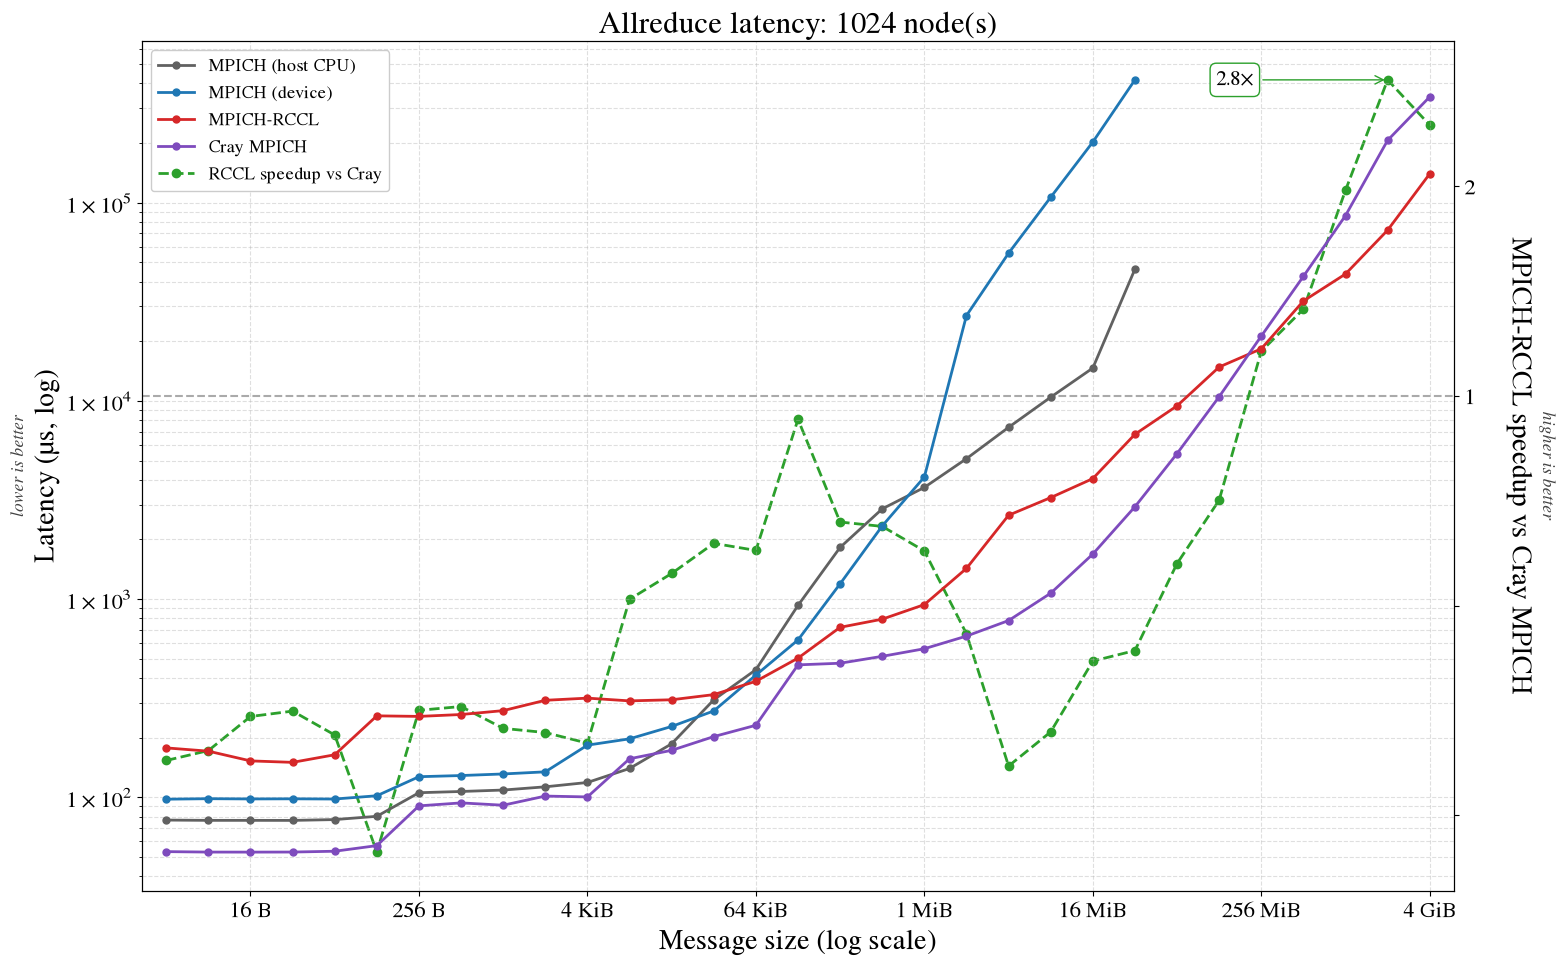

In [35]:
plot_latency_vs_size(1024)          # node count: 1, 2, 4, 8, ... 1024, 2048, 4096

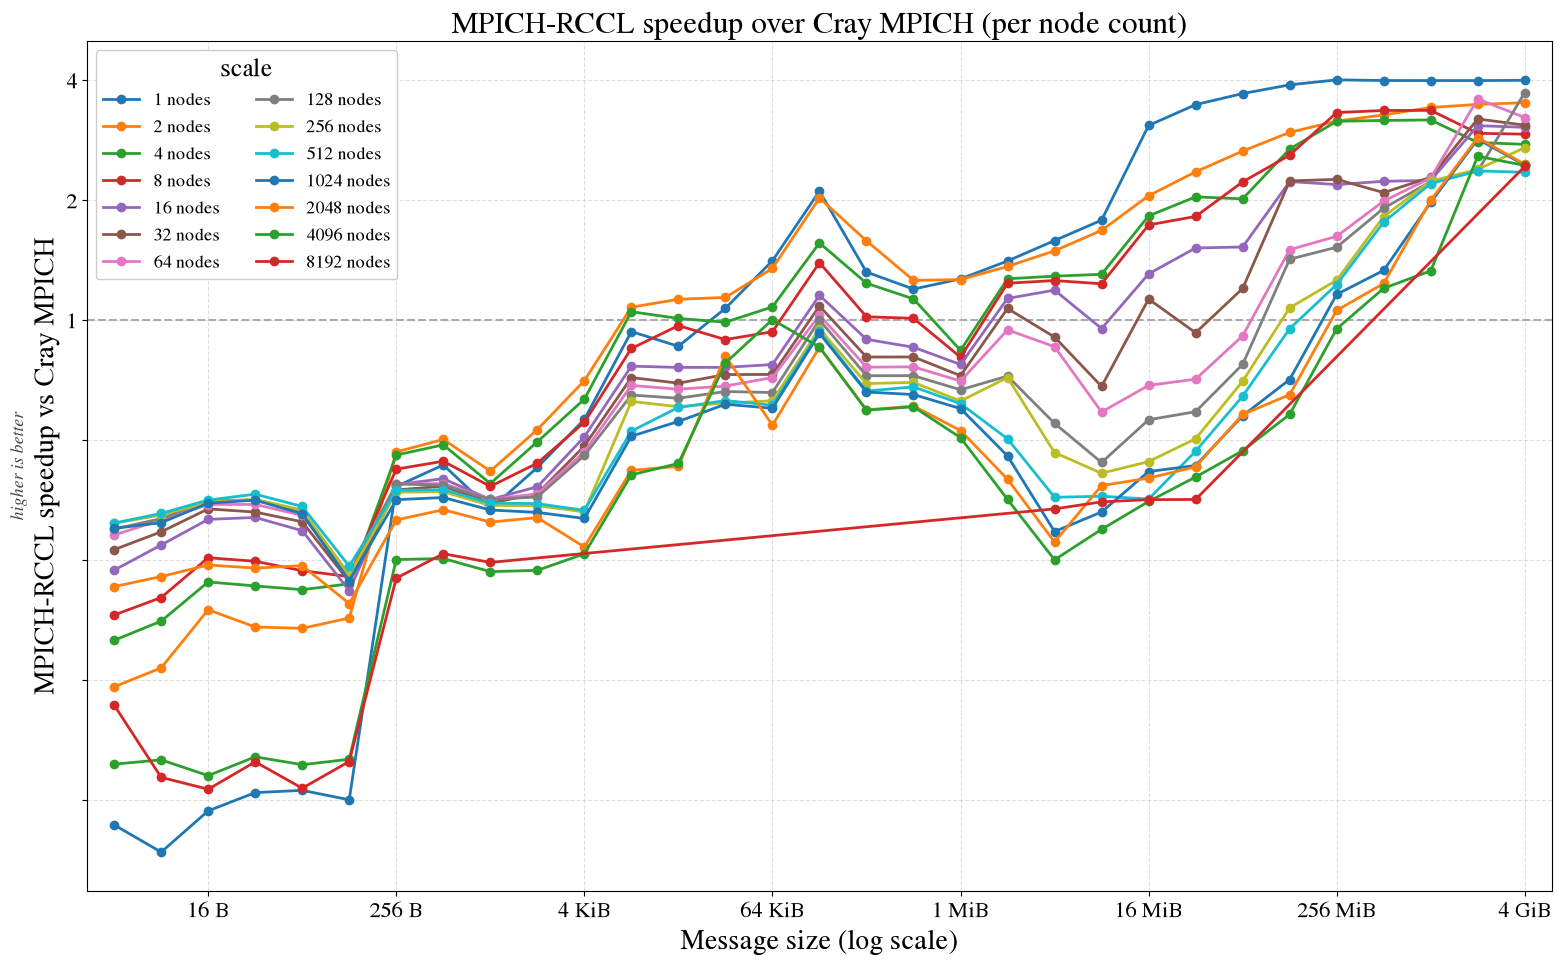

In [36]:
plot_speedup_vs_size("T")        # baseline: "D"=Cray, "B"=MPICH (device)

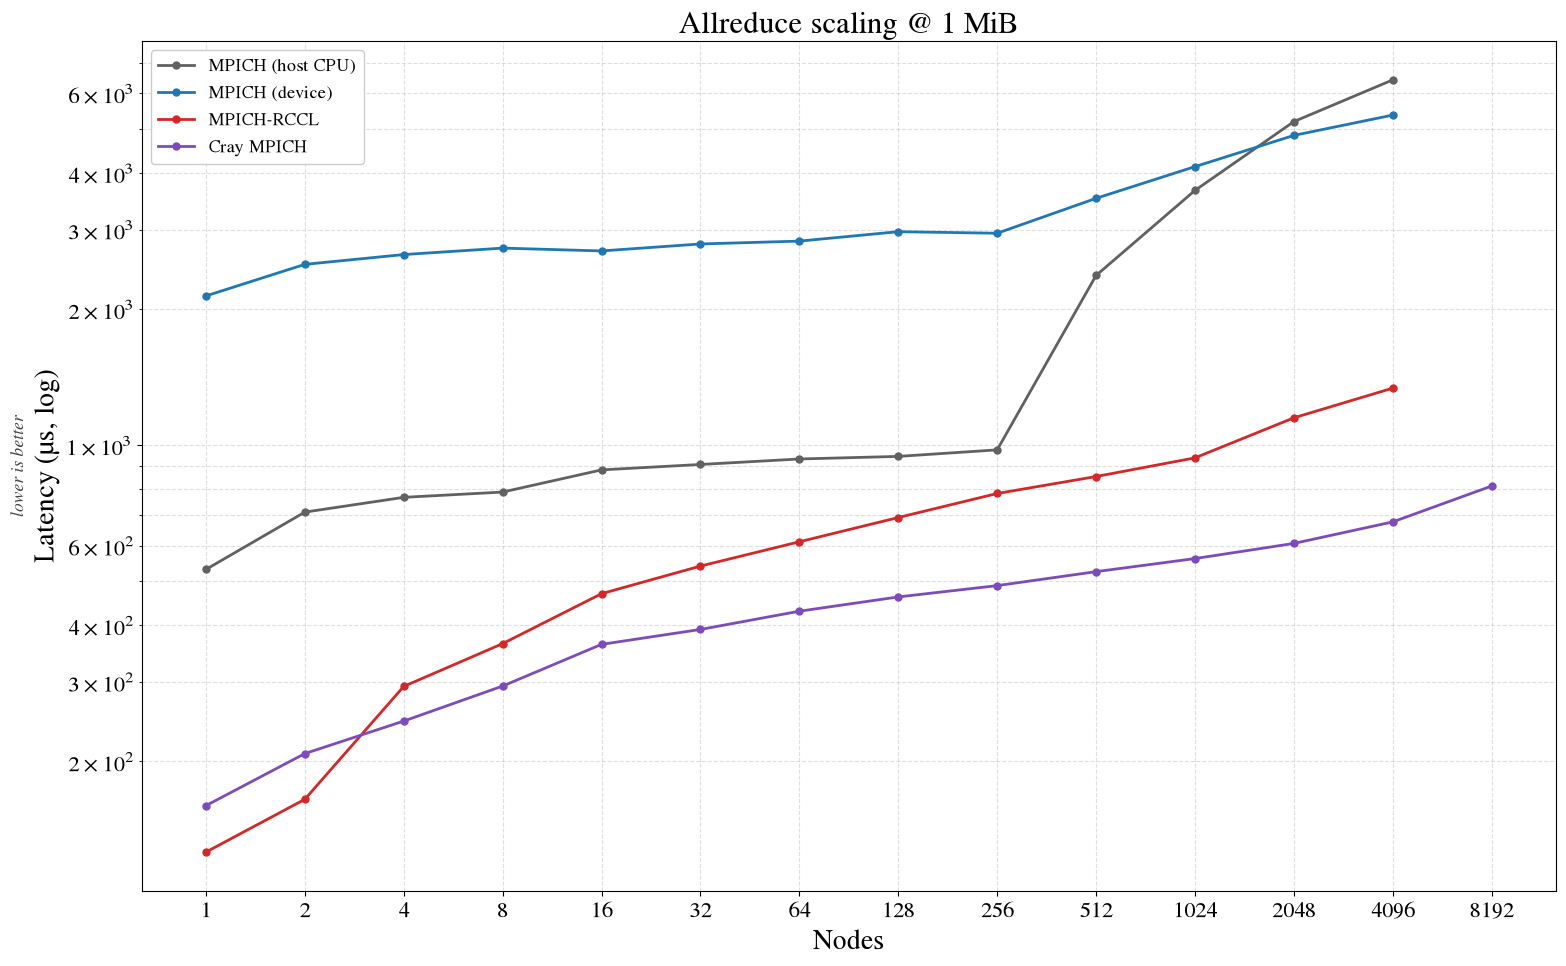

In [37]:
plot_scaling("1MiB")             # size: "1KiB", "16MiB", "1GiB", "2GiB", "4GiB", ... (raw bytes also ok)

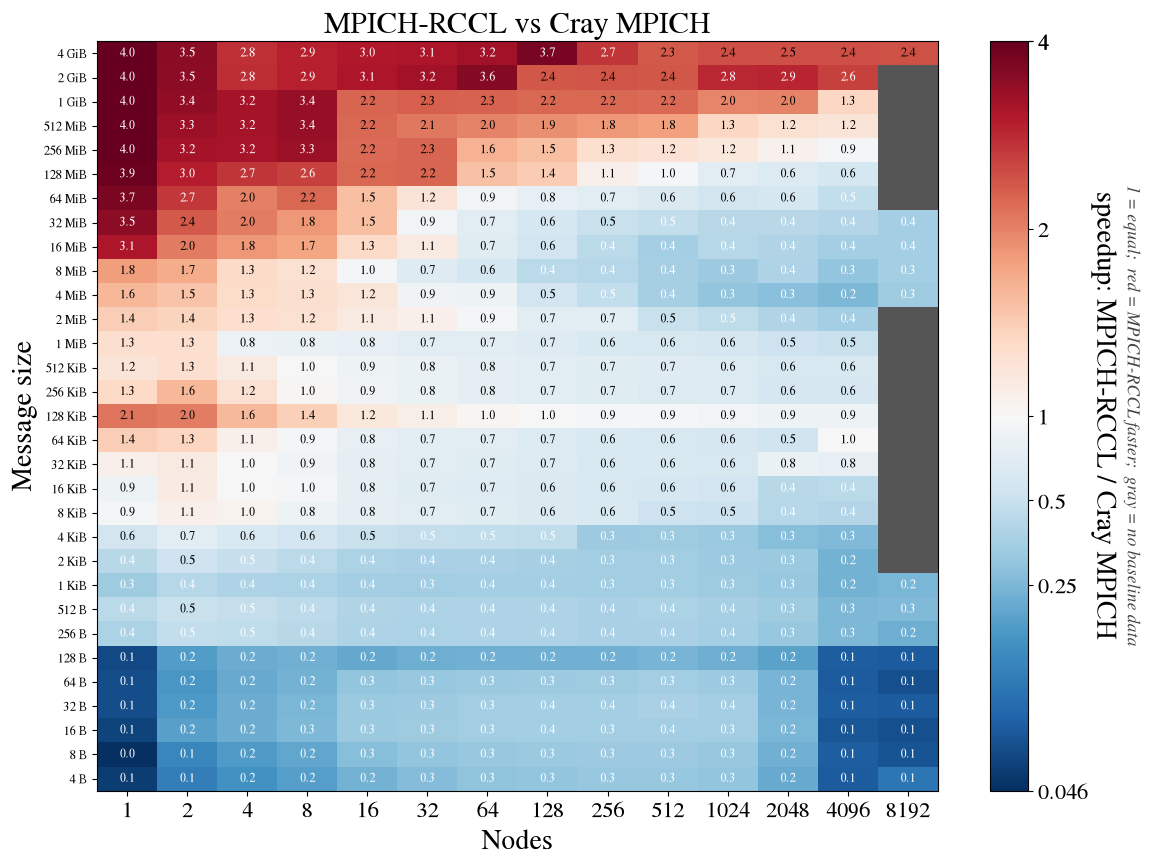

In [38]:
plot_crossover("T")              # crossover heatmap: red = MPICH-RCCL faster, gray = no Cray data

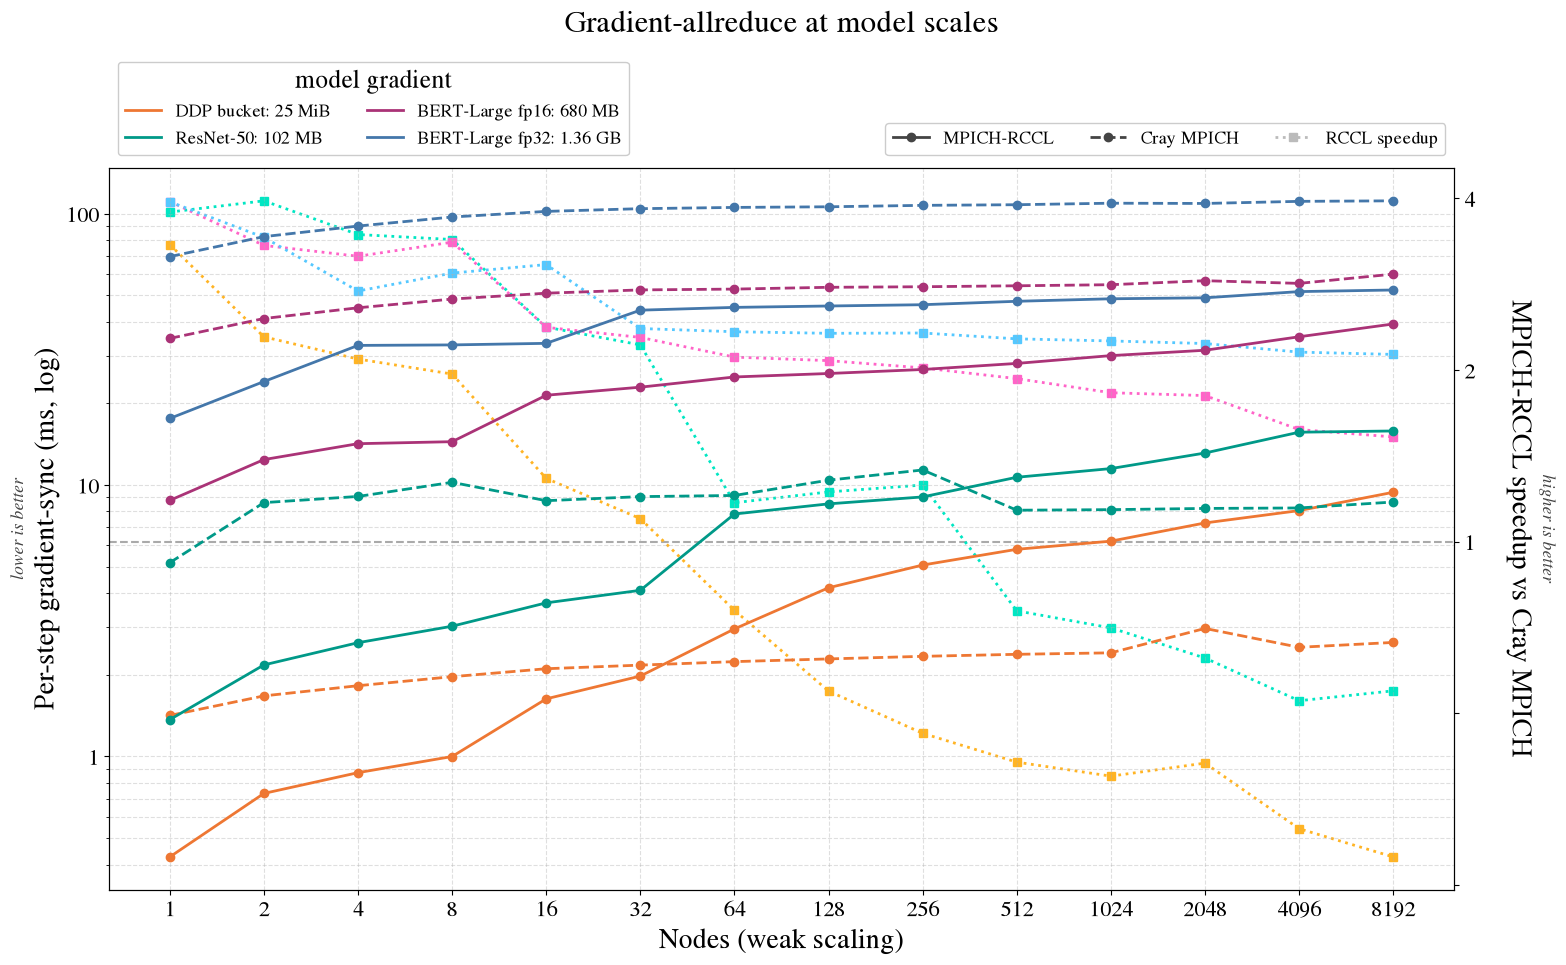

,model,nodes,rccl_ms,base_ms,knob_ms,eff_GBps,speedup,knob_spd,vs_MPICH
0,DDP bucket: 25 MiB,1,0.427,1.416,1.416,61.452,3.320,3.320,296.086
1,DDP bucket: 25 MiB,2,0.731,1.672,1.672,35.860,2.287,2.287,399.828
2,DDP bucket: 25 MiB,4,0.872,1.823,1.823,30.070,2.091,2.091,321.651
3,DDP bucket: 25 MiB,8,1.000,1.968,1.968,26.219,1.968,1.968,300.125
4,DDP bucket: 25 MiB,16,1.631,2.105,2.105,16.077,1.291,1.291,180.808
5,DDP bucket: 25 MiB,32,1.978,2.171,2.171,13.252,1.097,1.097,153.061
6,DDP bucket: 25 MiB,64,2.951,2.236,2.236,8.882,0.758,0.758,102.725
7,DDP bucket: 25 MiB,128,4.184,2.288,2.288,6.266,0.547,0.547,73.173
8,DDP bucket: 25 MiB,256,5.073,2.339,2.339,5.168,0.461,0.461,61.417
9,DDP bucket: 25 MiB,512,5.798,2.379,2.379,4.521,0.410,0.410,53.629


In [39]:
# ML gradient-sync (2 plots). solid=RCCL, dashed=Cray (both circles); light dotted square = RCCL speedup (right axis)
df_ml = plot_ml_sync(source="exact")   # (1) exact model sizes (results_ml)
# plot_ml_sync("D", source="near")             # (2) nearest power-of-2 estimate (main sweep)
df_ml.round(3)

saved -> headline_bert.svg


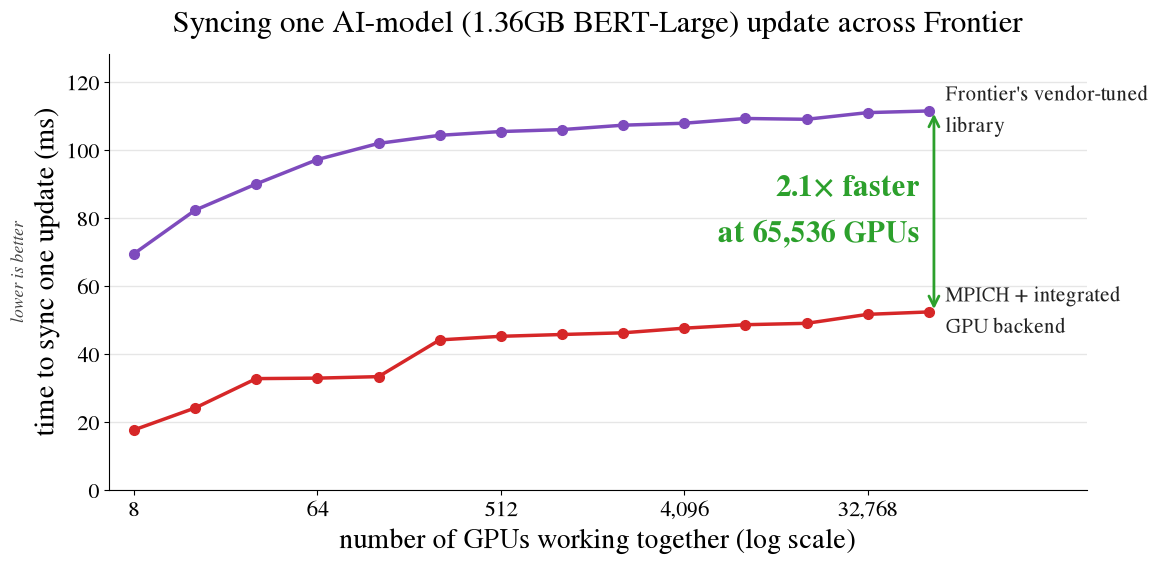

In [40]:
# === Layperson headline: BERT-Large sync time vs machine scale ==============
# For slides/editorial -- no HPC background needed. Time to combine one full-
# precision BERT-Large gradient (1.36 GB, one all-reduce per training step)
# as the run grows from 8 GPUs to 65,536 (8,192 Frontier nodes). Two lines:
# the vendor-tuned library vs this work, speedup at full scale as the hero
# number. Pulls data_ml (exact model sizes) like plot_ml_sync. x axis is GPUs
# (= nodes x 8), the number a lay reader can picture. Linear y: flat-is-good.
# Saves headline_bert.svg next to the notebook (text as vector paths).
def plot_headline(size=1360000000, save="headline_bert.svg"):
    cfgs = [("T", "Frontier's vendor-tuned\nlibrary"),
            ("C", "MPICH + integrated\nGPU backend")]
    d = {c: data_ml[(data_ml.config == c) & (data_ml["size"] == size)].sort_values("nodes")
         for c, _ in cfgs}
    if any(len(v) == 0 for v in d.values()):
        print(f"plot_headline: missing T/C ML data at size={size}"); return
    fig, ax = plt.subplots(figsize=(12, 6))
    for c, lab in cfgs:
        gpus, ms = d[c].nodes.values * 8, d[c].avg.values / 1000.0
        ax.plot(gpus, ms, marker="o", ls="-", lw=2.5, ms=7, color=STYLE[c]["color"])
        ax.annotate(lab, xy=(gpus[-1], ms[-1]), xytext=(12, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=15, color="#222222")
    tg, tc = d["T"].iloc[-1], d["C"].iloc[-1]
    ax.annotate("", xy=(tg.nodes * 8 * 1.06, tg.avg / 1000.0),
                xytext=(tc.nodes * 8 * 1.06, tc.avg / 1000.0),
                arrowprops=dict(arrowstyle="<->", color=SPEEDUP_COLOR, lw=2))
    ax.annotate(f"{tg.avg / tc.avg:.1f}× faster\nat 65,536 GPUs", va="center", ha="right",
                xy=(tg.nodes * 8 * 0.9, (tg.avg + tc.avg) / 2000.0),
                fontsize=22, fontweight="bold", color=SPEEDUP_COLOR)
    ax.set_xscale("log", base=2)
    ax.set_xticks([8, 64, 512, 4096, 32768])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlim(6, 8 * 8192 * 6)          # right margin carries the line-end labels
    ax.set_ylim(0, max(d["T"].avg.max(), d["C"].avg.max()) / 1000.0 * 1.15)
    ax.set_xlabel("number of GPUs working together (log scale)")
    ylabel2(ax, "time to sync one update (ms)", "lower is better", "left")
    ax.set_title("Syncing one AI-model (1.36GB BERT-Large) update across Frontier", pad=16)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, axis="y", color="#e6e6e6", lw=1); ax.set_axisbelow(True)
    fig.patch.set_facecolor("white"); fig.tight_layout()
    if save:
        fig.savefig(save, bbox_inches="tight")
        print(f"saved -> {save}")
    plt.show()

plot_headline()